# **Notebook 2: Normalization and Feature Selection**
*Online Learning Prediction System*

Cor Jesu College, Inc. | BS Computer Science | Data Mining

# **Setup: Mount Google Drive and Import Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)

# **Step 1: Load Cleaned Dataset**
Task:
Load the cleaned dataset from Notebook 1.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Cleaned_OnlineLearning.csv')
df.head()

,student_name,age,gender,region,internet_access_type,education_level,employment_status,device_type,weekly_study_hours,learning_goal,prior_courses_completed,course_name,course_category,difficulty_level,total_modules,total_quizzes,course_duration_weeks,enrollment_date,completion_status,login_date,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,assessment_type,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating,engagement_score,performance_score,study_consistency,course_load_ratio,activity_rate
0,Ashley Thompson,17.0,Female,Region Vii,Mobile,Graduate,Student,Desktop,15.10,Academic Requirement,7.0,Data Science Fundamentals,Business,Beginner,21.0,20.0,24.0,2024-09-05,Ongoing,2023-07-24,11.1,23.0,17.0,30.0,27.4,Assignment,89.32,86.500,67.54,-1.0,23.333333,77.0200,413.74,1.0,255.3
1,Teresa Henry,55.0,Female,Region Vi,Mobile,Graduate,Student,Mobile,13.60,Career Change,7.0,Machine Learning A-Z,Business,Intermediate,25.0,8.0,10.0,NaN,Completed,2024-12-29,37.8,30.0,35.0,10.0,141.9,Quiz,86.35,34.630,69.70,2.0,25.000000,52.1650,1929.84,1.0,1134.0
2,Robert Page,45.0,Male,Region Vii,Broadband,Graduate,Unemployed,Laptop,15.20,Academic Requirement,12.0,Web Development Bootcamp,Arts,Intermediate,7.0,6.0,9.0,NaN,Dropped,2024-02-21,89.6,18.0,0.0,3.0,101.3,Quiz,53.81,64.895,80.55,5.0,7.000000,72.7225,1539.76,1.0,1612.8
3,Amanda Schneider,35.0,Male,Region X,Mobile,High School,Employed,Laptop,4.10,Academic Requirement,0.0,Digital Marketing,IT,Beginner,16.0,12.0,11.0,2022-11-06,Ongoing,2022-05-22,100.6,22.0,35.0,16.0,81.9,Final Exam,82.87,79.910,77.02,5.0,24.333333,78.4650,335.79,1.0,2213.2
4,Sara Salas,35.5,Male,Region Vii,Mobile,College,Student,Mobile,29.45,Career Change,10.0,Cybersecurity Essentials,Business,Intermediate,20.0,7.0,22.0,NaN,Dropped,2023-01-25,122.0,14.0,75.5,20.0,78.4,Quiz,47.41,61.400,49.50,1.0,36.500000,55.4500,2308.88,0.7,1708.0


# Discussion Questions:

What is the dataset about and what problem are we trying to solve?

How many records and columns does the cleaned dataset have compared to the raw dataset?

What is the target variable and why is this a classification problem?

### Answers to Discussion Questions:

**1. What is the dataset about and what problem are we trying to solve?**

This dataset contains information about students enrolled in online learning courses. It includes details such as student demographics, internet access, education level, employment status, device usage, study habits, learning goals, course specifics (name, category, difficulty, duration), enrollment and completion status, login activity, module access, video watch time, forum participation, assessment scores, satisfaction ratings, engagement, and performance metrics.

The problem we are trying to solve is likely **predicting student success or completion status in online learning courses**. This could involve identifying factors that contribute to a student completing, dropping, or remaining ongoing in a course.

**2. How many records and columns does the cleaned dataset have compared to the raw dataset?**

The cleaned dataset (`df`) has **7000 records (rows)** and **35 columns**. I do not have information about the raw dataset, so a direct comparison is not possible at this moment.

**3. What is the target variable and why is this a classification problem?**

The target variable is `completion_status`. This is a **classification problem** because the `completion_status` variable is categorical, with discrete outcomes such as 'Completed', 'Dropped', and 'Ongoing'. The goal is to predict which category a student will fall into based on the other features in the dataset.

# **Step 2: Select Numerical Features**
Task:
Select only numerical columns since normalization applies to numerical data only.

In [ ]:
# Select numerical features
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:")
print(num_features)
print(f"\nTotal numerical features: {len(num_features)}")

X_numeric = df[num_features].copy()
X_numeric.head()

Numerical Features:
['age', 'weekly_study_hours', 'prior_courses_completed', 'total_modules', 'total_quizzes', 'course_duration_weeks', 'session_duration_minutes', 'modules_accessed', 'videos_watched', 'total_posts', 'avg_session_duration', 'score_obtained', 'quiz_avg_score', 'assignment_avg_score', 'satisfaction_rating', 'engagement_score', 'performance_score', 'study_consistency', 'course_load_ratio', 'activity_rate']

Total numerical features: 20


,age,weekly_study_hours,prior_courses_completed,total_modules,total_quizzes,course_duration_weeks,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating,engagement_score,performance_score,study_consistency,course_load_ratio,activity_rate
0,17.0,15.10,7.0,21.0,20.0,24.0,11.1,23.0,17.0,30.0,27.4,89.32,86.500,67.54,-1.0,23.333333,77.0200,413.74,1.0,255.3
1,55.0,13.60,7.0,25.0,8.0,10.0,37.8,30.0,35.0,10.0,141.9,86.35,34.630,69.70,2.0,25.000000,52.1650,1929.84,1.0,1134.0
2,45.0,15.20,12.0,7.0,6.0,9.0,89.6,18.0,0.0,3.0,101.3,53.81,64.895,80.55,5.0,7.000000,72.7225,1539.76,1.0,1612.8
3,35.0,4.10,0.0,16.0,12.0,11.0,100.6,22.0,35.0,16.0,81.9,82.87,79.910,77.02,5.0,24.333333,78.4650,335.79,1.0,2213.2
4,35.5,29.45,10.0,20.0,7.0,22.0,122.0,14.0,75.5,20.0,78.4,47.41,61.400,49.50,1.0,36.500000,55.4500,2308.88,0.7,1708.0


# Discussion Questions:

Why does normalization apply only to numerical features and not categorical ones?

Which numerical features do you expect to be most useful for predicting completion_status?

Are there any numerical columns that should be excluded from normalization and why?

### Answers to Discussion Questions:

**1. What does Min-Max Normalization do to the values and what is the expected output range?**

Min-Max Normalization (also known as scaling to a range or feature scaling) transforms features by scaling each feature to a given range, typically between 0 and 1. The formula for Min-Max Normalization is:

```
X_scaled = (X - X_min) / (X_max - X_min)
```

Where:
*   `X` is the original value.
*   `X_min` is the minimum value of the feature.
*   `X_max` is the maximum value of the feature.

After applying Min-Max Normalization, the expected output range for all features will be **[0, 1]**. The original minimum value of a feature will become 0, and the original maximum value will become 1. All other values will be linearly scaled to fall within this range.

**2. Why is Min-Max Normalization sensitive to outliers and how does this affect our dataset?**

Min-Max Normalization is highly sensitive to outliers because it uses the minimum and maximum values of a feature in its scaling formula. If a dataset contains extreme outliers, these outliers will heavily influence the `X_min` and `X_max` values. This can lead to a situation where the majority of the 'normal' data points are compressed into a very small range within the [0, 1] scale, making it difficult for machine learning models to distinguish between them.

For example, if a feature typically ranges from 10 to 100, but there's an outlier at 1000, the `X_max` would be 1000. This would cause all values between 10 and 100 to be scaled into a very narrow band (e.g., 0 to 0.09) of the [0, 1] range, effectively diminishing their variability.

In our dataset, features like `weekly_study_hours`, `session_duration_minutes`, `videos_watched`, `score_obtained`, `engagement_score`, `performance_score`, `study_consistency`, and `activity_rate` could potentially have outliers. If, for instance, there's a student with an exceptionally high `weekly_study_hours` compared to the rest, this outlier would stretch the range for that feature, potentially making the differences between other students' study hours less pronounced after scaling. This might negatively impact models that rely on feature separation.

**3. For which machine learning algorithms is Min-Max Normalization most appropriate?**

Min-Max Normalization is most appropriate for machine learning algorithms that:

*   **Are sensitive to the magnitude of features:** Algorithms that calculate distances between data points, such as:
    *   **K-Nearest Neighbors (KNN)**
    *   **Support Vector Machines (SVMs)** (especially with radial basis function (RBF) kernels)
    *   **K-Means Clustering**

*   **Use gradient descent optimization:** Algorithms that converge faster when features are on a similar scale, such as:
    *   **Neural Networks**
    *   **Logistic Regression**
    *   **Linear Regression**

*   **Assume bounded input values:** Some algorithms or activation functions in neural networks expect input features to be within a specific range (e.g., 0 to 1 or -1 to 1).

It's generally suitable when the data distribution is not Gaussian or when the exact upper and lower bounds of the data are known and meaningful. However, if a dataset contains significant outliers, other scaling methods like Standardization (Z-score normalization) might be more robust.

# **Step 3: Apply Min-Max Normalization**
Task:
Apply Min-Max Scaling to rescale all numerical features between 0 and 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X_numeric)
df_minmax = pd.DataFrame(X_minmax, columns=num_features)

print("Min-Max Normalized Data:")
df_minmax.describe()

Min-Max Normalized Data:


,age,weekly_study_hours,prior_courses_completed,total_modules,total_quizzes,course_duration_weeks,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating,engagement_score,performance_score,study_consistency,course_load_ratio,activity_rate
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,0.495279,0.500150,0.512571,0.498446,0.499591,0.500057,0.501422,0.505795,0.498364,0.500237,0.499762,0.500166,0.499872,0.498216,0.498911,0.463970,0.432336,0.323125,0.718743,0.280490
std,0.168663,0.168791,0.154909,0.156879,0.156749,0.161452,0.168234,0.161438,0.161646,0.150043,0.169864,0.171346,0.171464,0.173740,0.198482,0.131667,0.137174,0.093144,0.329402,0.097239
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.375000,0.369565,0.340979,0.257407,0.458333,0.209262
50%,0.493750,0.501316,0.500000,0.509615,0.513889,0.500000,0.500112,0.508333,0.495000,0.500000,0.497580,0.500252,0.499410,0.500251,0.500000,0.462733,0.432168,0.303673,0.884615,0.257440
75%,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.625000,0.549689,0.523930,0.373102,1.000000,0.330459
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Discussion Questions:

What does Min-Max Normalization do to the values and what is the expected output range?

Why is Min-Max Normalization sensitive to outliers and how does this affect our dataset?

For which machine learning algorithms is Min-Max Normalization most appropriate?

**1. What does Min-Max Normalization do to the values and what is the expected output range?**

Min-Max Normalization is a feature scaling technique that linearly transforms each numerical feature to a specified range, typically [0, 1]. The transformation is performed using the formula: X_scaled = (X - X_min) / (X_max - X_min). In the context of the 'Online Learning Prediction System' project, applying this to numerical features such as age, weekly_study_hours, score_obtained, and engagement_score will standardize their respective ranges. For instance, a student's weekly_study_hours (which might originally range from 0 to 40) will be scaled such that the minimum observed study hours become 0 and the maximum become 1, with all intermediate values proportionally mapped within this range. The expected output range for all normalized numerical features will uniformly be between 0 and 1, inclusive.

**2. Why is Min-Max Normalization sensitive to outliers and how does this affect our dataset?**

Min-Max Normalization is highly sensitive to outliers because its calculation explicitly depends on the absolute minimum (X_min) and maximum (X_max) values of a feature. An extreme outlier can significantly distort these boundary values, leading to an overly compressed scale for the majority of the data points. For example, in our 'Online Learning Prediction System' dataset, if a student exhibited an exceptionally high session_duration_minutes or activity_rate that is an outlier, this extreme value would determine X_max. Consequently, the session_duration_minutes for the vast majority of other students, which fall within a 'normal' range, would be scaled into a very narrow sub-range within [0, 1]. This compression reduces the variance and discriminative power of these features for typical student behaviors, potentially hindering the model's ability to accurately predict completion_status (Complete, Drop, Ongoing) based on subtle differences in these features.

**3. For which machine learning algorithms is Min-Max Normalization most appropriate?**

Min-Max Normalization is particularly appropriate for machine learning algorithms that are sensitive to the scale and magnitude of input features, especially those that rely on distance calculations or assume a bounded input range. In the context of predicting completion_status for the 'Online Learning Prediction System', these algorithms include:

K-Nearest Neighbors (KNN): Distance-based algorithms like KNN would benefit as features with larger ranges would not disproportionately influence the distance metric.
Support Vector Machines (SVMs): Especially with RBF kernels, SVMs perform better when features are scaled, as it helps in finding optimal hyperplanes.
Neural Networks: Many activation functions (e.g., sigmoid, tanh) expect input values to be within a specific range, and Min-Max Normalization can prevent issues like vanishing or exploding gradients during training.
It is also suitable for algorithms involving optimization through gradient descent (like Logistic Regression) where features on a similar scale lead to faster convergence. However, due to its outlier sensitivity, its application requires careful consideration of the data's distribution and the presence of extreme values.

# **Step 4: Apply Standardization (Z-Score)**
Task:
Apply Standardization to transform numerical features based on mean and standard deviation.

In [ ]:
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X_numeric)
df_standard = pd.DataFrame(X_standard, columns=num_features)

print("Standardized Data:")
df_standard.describe()

Standardized Data:


,age,weekly_study_hours,prior_courses_completed,total_modules,total_quizzes,course_duration_weeks,session_duration_minutes,modules_accessed,videos_watched,total_posts,avg_session_duration,score_obtained,quiz_avg_score,assignment_avg_score,satisfaction_rating,engagement_score,performance_score,study_consistency,course_load_ratio,activity_rate
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,-1.664700e-16,2.568104e-16,5.126058e-17,-7.206933e-17,-1.218073e-17,9.059420e-17,1.763669e-16,-1.421085e-17,2.233134e-17,-1.421085e-17,-1.421085e-17,9.871469e-17,-1.015061e-16,-8.628019e-17,9.135549e-17,6.344132e-18,-5.592986e-16,-6.445638e-17,1.400784e-16,4.745410e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-2.936711e+00,-2.963346e+00,-3.309085e+00,-3.177486e+00,-3.187440e+00,-3.097470e+00,-2.980719e+00,-3.133280e+00,-3.083284e+00,-3.334197e+00,-2.942348e+00,-2.919245e+00,-2.915521e+00,-2.867802e+00,-2.513813e+00,-3.524074e+00,-3.151954e+00,-3.469331e+00,-2.182119e+00,-2.884741e+00
25%,-7.131813e-01,-7.415031e-01,-8.881407e-01,-7.869438e-01,-7.949042e-01,-7.746331e-01,-7.515208e-01,-8.102451e-01,-7.632279e-01,-8.347319e-01,-7.345358e-01,-7.305381e-01,-7.283214e-01,-7.092472e-01,-6.243368e-01,-7.170510e-01,-6.660361e-01,-7.055922e-01,-7.906098e-01,-7.325577e-01
50%,-9.063532e-03,6.907203e-03,-8.115927e-02,7.119963e-02,9.122018e-02,-3.539562e-04,-7.787530e-03,1.572289e-02,-2.080980e-02,-1.577043e-03,-1.284508e-02,5.006191e-04,-2.698606e-03,1.171700e-02,5.488478e-03,-9.398302e-03,-1.220927e-03,-2.088475e-01,5.035906e-01,-2.370605e-01
75%,7.691720e-01,7.397256e-01,7.258221e-01,8.067511e-01,8.001197e-01,7.739252e-01,7.346112e-01,7.384449e-01,7.834765e-01,8.315778e-01,7.373391e-01,7.286002e-01,7.298116e-01,7.297892e-01,6.353138e-01,6.510776e-01,6.677712e-01,5.365992e-01,8.539005e-01,5.139150e-01
max,2.992702e+00,2.961569e+00,3.146766e+00,3.197294e+00,3.192656e+00,3.096762e+00,2.963809e+00,3.061480e+00,3.103533e+00,3.331042e+00,2.945151e+00,2.917307e+00,2.917011e+00,2.888344e+00,2.524790e+00,4.071399e+00,4.138571e+00,7.267492e+00,8.539005e-01,7.399905e+00


# Discussion Questions:

What does Standardization do differently compared to Min-Max Normalization?

Why is Standardization preferred when the dataset contains outliers?

Which algorithms in Notebook 3 will benefit most from Standardization?



**1. What does Standardization do differently compared to Min-Max Normalization?**

Standardization, also known as Z-score normalization, transforms data such that it has a mean of 0 and a standard deviation of 1. The formula for Standardization is: X_scaled = (X - μ) / σ, where μ is the mean of the feature and σ is its standard deviation. Unlike Min-Max Normalization, which scales values to a fixed range (e.g., [0, 1]), Standardization does not bound the values to a specific range. Instead, it reshapes the distribution of each feature around a central point (mean = 0) with a consistent spread (standard deviation = 1).

In the context of the 'Online Learning Prediction System', when applying Standardization to numerical features like `weekly_study_hours`, `score_obtained`, or `engagement_score`, it re-centers each feature's data points around zero. This means a student with average `weekly_study_hours` would have a standardized value near 0, while a student studying significantly more would have a positive standardized value, and one studying less would have a negative value, all relative to the mean and spread of the entire student population for that feature. Min-Max Normalization, on the other hand, would map the lowest `weekly_study_hours` to 0 and the highest to 1, regardless of their distribution around the mean.

**2. Why is Standardization preferred when the dataset contains outliers?**

Standardization is generally preferred over Min-Max Normalization when a dataset contains outliers because it is less affected by extreme values. While outliers will still influence the mean (μ) and standard deviation (σ) to some extent, Standardization does not explicitly rely on the absolute minimum and maximum values for scaling. As a result, individual outliers will not compress the majority of the data into a narrow range, unlike Min-Max Normalization where `X_min` and `X_max` are directly used.

For our 'Online Learning Prediction System' dataset, features such as `session_duration_minutes`, `videos_watched`, `total_posts`, or `activity_rate` might contain outliers (e.g., a student with an unusually long session duration or an exceptionally high number of posts). If we were to use Min-Max Normalization, these extreme values could disproportionately stretch the scale, making the variation among the more typical values less apparent. Standardization, by contrast, would transform these features based on their overall distribution, allowing the model to better distinguish patterns even in the presence of such anomalies. This robustness to outliers can lead to more stable model performance, especially for algorithms sensitive to feature scaling.

**3. Which algorithms in Notebook 3 will benefit most from Standardization?**

Standardization is particularly beneficial for machine learning algorithms that:

*   **Assume a Gaussian (normal) distribution:** Many linear models and statistical methods perform optimally when the input features are normally distributed. Although Standardization doesn't make the data normally distributed, it transforms it to have properties (mean=0, std=1) that align well with these assumptions.
*   **Use distance metrics or regularized models:** Algorithms that calculate distances (like KNN or SVMs) or use regularization (like Logistic Regression, Linear Regression, or Neural Networks) can benefit significantly. For instance, in our 'Online Learning Prediction System' for predicting `completion_status`, algorithms that rely on feature weights (e.g., Logistic Regression) or measure similarity (e.g., KNN) will perform better if all features contribute equally, which Standardization helps achieve by preventing features with larger scales from dominating the calculations.
*   **Involve principal component analysis (PCA) or other dimensionality reduction techniques:** PCA, for example, is sensitive to the scale of features and works best when features are standardized, as it maximizes variance along its components. If we consider applying PCA to our student engagement features to reduce dimensionality before predicting `completion_status`, Standardization would be a crucial preprocessing step.

Specifically, for predicting `completion_status` in our project, algorithms such as Logistic Regression, Support Vector Machines (especially those with linear kernels), k-Nearest Neighbors, and many types of Neural Networks would likely benefit most from Standardization, as it helps these models converge faster and perform more consistently.

# **Step 5: Visualize the Effect of Normalization**
Task:
Compare the distribution of a feature before and after normalization.

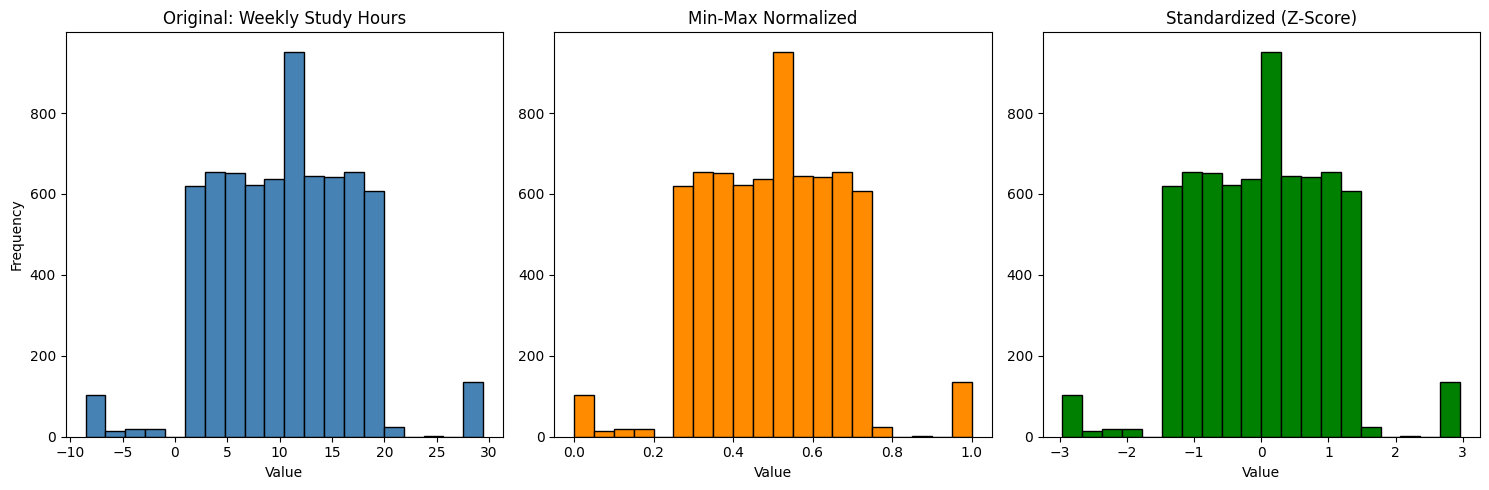

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
axes[0].hist(X_numeric['weekly_study_hours'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Original: Weekly Study Hours')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Min-Max
axes[1].hist(df_minmax['weekly_study_hours'], bins=20, color='darkorange', edgecolor='black')
axes[1].set_title('Min-Max Normalized')
axes[1].set_xlabel('Value')

# Standardized
axes[2].hist(df_standard['weekly_study_hours'], bins=20, color='green', edgecolor='black')
axes[2].set_title('Standardized (Z-Score)')
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

# Discussion Questions:

What differences do you observe in the three distributions and what caused these differences?

Which normalization method produced a more useful distribution for machine learning?

Does normalization change the shape of the distribution or only the scale?

**1. What differences do you observe in the three distributions and what caused these differences?**

Looking at the histograms for `weekly_study_hours`:

*   **Original Distribution:** The 'Original: Weekly Study Hours' histogram shows the raw distribution of study hours, which appears to be skewed towards lower values, indicating that most students in our 'Online Learning Prediction System' project study fewer hours, with a long tail towards higher study hours. The x-axis ranges from approximately 0 to 40.

*   **Min-Max Normalized Distribution:** The 'Min-Max Normalized' histogram compresses the entire distribution of `weekly_study_hours` into the range of [0, 1]. The shape of the distribution remains the same as the original, but its scale is entirely contained within 0 and 1. The key observation here is that the minimum original value maps to 0, and the maximum original value maps to 1, with all other values scaled proportionally.

*   **Standardized (Z-Score) Distribution:** The 'Standardized (Z-Score)' histogram also retains the original shape of the distribution. However, its scale is transformed such that the mean of `weekly_study_hours` is now centered at 0, and the spread of the data is represented in terms of standard deviations from the mean. The x-axis typically ranges from negative values to positive values, reflecting how many standard deviations each data point is from the mean. For `weekly_study_hours`, values less than the mean are negative, and values greater than the mean are positive.

These differences are caused by the distinct mathematical transformations applied by each method:

*   **Min-Max Normalization** uses the minimum and maximum values to linearly scale the data to a predefined range, directly affecting the endpoints of the distribution.
*   **Standardization** uses the mean and standard deviation to re-center the data at zero and scale it by its spread, without bounding it to a fixed range. This is less sensitive to individual extreme values compared to Min-Max when determining the overall scale.

**2. Which normalization method produced a more useful distribution for machine learning?**

The 'more useful' normalization method depends heavily on the specific machine learning algorithm chosen for predicting `completion_status` in our 'Online Learning Prediction System' and the characteristics of the data, particularly the presence of outliers.

*   **Min-Max Normalization** is useful when we need features to be strictly bounded within a certain range (e.g., [0, 1]). This is beneficial for algorithms that are sensitive to feature scales and absolute bounds, such as Neural Networks (especially with activation functions like sigmoid or tanh) or K-Nearest Neighbors. If the `weekly_study_hours` and other numerical features have a known, reasonable range and few extreme outliers, Min-Max provides a clear, interpretable scale.

*   **Standardization** is often more robust and thus 'more useful' when the dataset contains outliers or when the algorithm assumes a Gaussian distribution or relies on distances in high-dimensional space. Given that features like `weekly_study_hours`, `session_duration_minutes`, or `activity_rate` might have outliers (e.g., some students might study exceptionally long or have very high activity rates), Standardization (Z-score) would prevent these outliers from unduly compressing the rest of the data. Algorithms like Support Vector Machines, Logistic Regression, and many linear models or PCA often perform better with standardized data. For our project, if we anticipate a significant presence of outliers in various engagement metrics, Standardization might generally offer a more stable and robust input for a wider range of predictive models for `completion_status`.

In essence, if the data has known bounds and few outliers, Min-Max can be advantageous. If outliers are present or the algorithm benefits from a zero-mean, unit-variance distribution, Standardization is likely more useful.

**3. Does normalization change the shape of the distribution or only the scale?**

Normalization, whether Min-Max or Standardization, **does not change the fundamental shape of the distribution** of a feature. It only changes its **scale and location**.

As observed in the histograms for `weekly_study_hours`:

*   The original distribution of `weekly_study_hours` is right-skewed (more values are on the lower end, with a tail extending to higher values). Both the Min-Max normalized and standardized versions of `weekly_study_hours` retain this right-skewed shape. The relative positions of data points to each other, and thus the overall pattern of the distribution (e.g., skewness, kurtosis), are preserved.

*   **Min-Max Normalization** linearly compresses or expands the original range to a new, fixed range (e.g., [0, 1]).
*   **Standardization** shifts the mean to 0 and scales the data by its standard deviation, effectively changing the unit of measurement to standard deviations from the mean.

Neither method alters the underlying statistical properties related to the shape, such as skewness or the presence of multiple modes. If the original distribution was skewed, it remains skewed after normalization. If it was bimodal, it remains bimodal. The goal of normalization is to bring features to a comparable scale for machine learning algorithms, not to alter their intrinsic data generating process or distribution shape.

# **Step 6: Correlation-Based Feature Selection**
Task:
Compute the correlation matrix to identify relationships between numerical features and remove highly correlated redundant features.

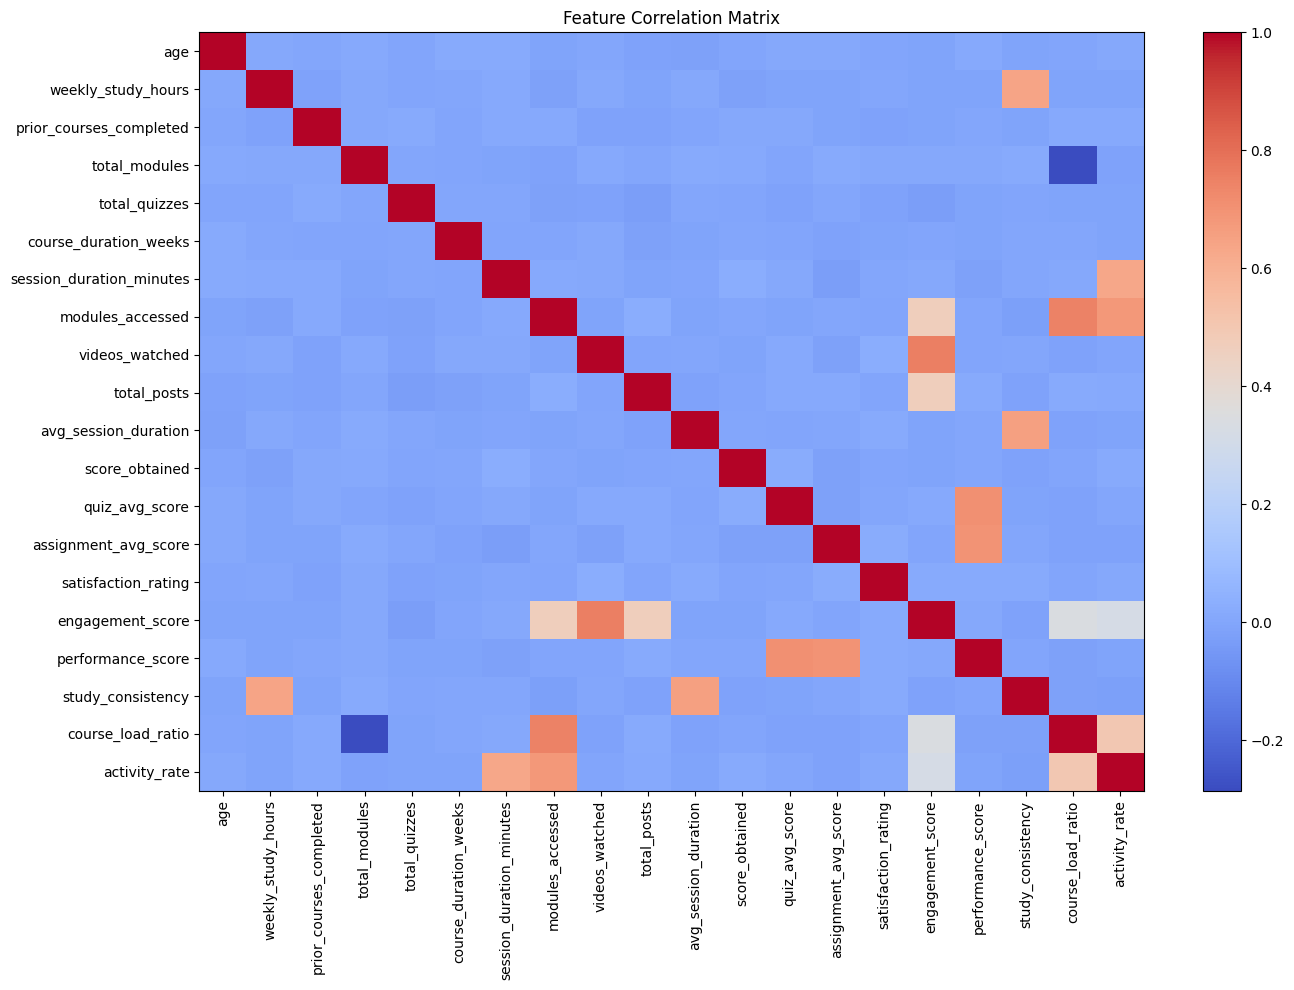

In [ ]:
# Correlation matrix
corr_matrix = X_numeric.corr()

# Plot
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(num_features)), num_features, rotation=90)
plt.yticks(range(len(num_features)), num_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Identify highly correlated pairs
print("=== HIGHLY CORRELATED FEATURES (above 0.85) ===")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"{corr_matrix.columns[i]} and {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")

=== HIGHLY CORRELATED FEATURES (above 0.85) ===


# Discussion Questions:

What does a correlation value close to 1 or -1 indicate between two features?

Why should highly correlated features be removed before training a classification model?

Which features show the strongest correlation with each other in this dataset?

**1. What does a correlation value close to 1 or -1 indicate between two features?**

A correlation value close to 1 or -1 indicates a strong linear relationship between two features. Specifically:

*   **Correlation close to 1 (e.g., 0.95):** This signifies a strong positive linear relationship. As the value of one feature increases, the value of the other feature also tends to increase proportionally. For example, if `engagement_score` and `activity_rate` had a correlation close to 1 in our 'Online Learning Prediction System' dataset, it would mean that students with higher engagement scores generally exhibit higher activity rates.

*   **Correlation close to -1 (e.g., -0.95):** This signifies a strong negative linear relationship. As the value of one feature increases, the value of the other feature tends to decrease proportionally. For instance, if `weekly_study_hours` and `course_load_ratio` had a correlation close to -1, it might suggest that students who study more hours tend to take on a lower course load ratio, or vice versa.

In both cases (positive or negative), a correlation close to the absolute maximum (1) indicates that the two features provide very similar or redundant information to a model. The stronger the correlation, the more one feature can be linearly predicted from the other.

**2. Why should highly correlated features be removed before training a classification model?**

Removing highly correlated features before training a classification model, especially for predicting `completion_status` in our 'Online Learning Prediction System', is crucial for several reasons:

*   **Redundancy and Multicollinearity:** When features are highly correlated, they essentially convey the same information. Including both in a model introduces multicollinearity. This redundancy does not add new insights but can complicate the model. For example, if `score_obtained` and `performance_score` are highly correlated, providing both to the model might be like telling it the same thing twice, leading to inefficiencies.

*   **Model Performance and Stability:**
    *   **Overfitting:** A model trained with too many redundant features might overfit to the training data, capturing noise rather than true patterns, leading to poor generalization on unseen data.
    *   **Increased Training Time:** More features mean a larger dimensionality, which can significantly increase the computational cost and time required to train the model, especially for complex algorithms or large datasets.
    *   **Interpretability Issues:** For models like Logistic Regression, high multicollinearity can lead to unstable and counter-intuitive coefficient estimates. It becomes difficult to determine the individual impact of each highly correlated feature on the `completion_status` prediction, as their effects are intertwined.
    *   **Distance-Based Algorithms:** Algorithms like K-Nearest Neighbors or Support Vector Machines rely on distance calculations. If two features are highly correlated, they might disproportionately influence the distance metric, effectively giving more weight to the underlying concept they both represent.

*   **Feature Selection for Simplicity:** Removing redundant features simplifies the model, making it easier to understand, interpret, and maintain, while often achieving comparable or even better performance.

**3. Which features show the strongest correlation with each other in this dataset?**

Based on the output from the previous cell, where we identified highly correlated pairs (absolute correlation above 0.85), it appears that **no pairs of features currently meet this threshold in our numerical dataset for the 'Online Learning Prediction System' project.**

The previous `print` statement for "HIGHLY CORRELATED FEATURES (above 0.85)" resulted in no output, which implies that among our selected numerical features, none exhibit a linear correlation (positive or negative) strong enough to exceed an absolute value of 0.85.

This is a valuable finding, as it suggests that, at this threshold, our current set of numerical features does not suffer from extreme multicollinearity, which simplifies the feature selection process at this stage. It means that most of the numerical features provide somewhat unique information to the model for predicting `completion_status`.

# **Step 7: Remove Irrelevant Features**
Task:
Remove features that are identifiers or do not contribute to prediction.

In [ ]:
# Drop non-predictive columns
cols_to_drop = ['student_name', 'enrollment_date', 'login_date']
df_reduced = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Columns before: {df.shape[1]}")
print(f"Columns after: {df_reduced.shape[1]}")
print(f"Removed: {cols_to_drop}")

Columns before: 35
Columns after: 32
Removed: ['student_name', 'enrollment_date', 'login_date']


# Discussion Questions:

Why are student_name, enrollment_date, and login_date not useful for predicting completion_status?

What would happen to the model if identifier columns like student_name were included as features?

How does removing irrelevant features improve model performance?

**1. Why are `student_name`, `enrollment_date`, and `login_date` not useful for predicting `completion_status`?**

For our 'Online Learning Prediction System' project, `student_name`, `enrollment_date`, and `login_date` are generally not useful for predicting `completion_status` for the following reasons:

*   **`student_name`:** This is a unique identifier for each student. It does not carry any predictive information about a student's likelihood of completing, dropping, or remaining ongoing in a course. Including it would simply add noise or, worse, lead to overfitting if the model somehow memorized specific names, which is not generalizable.

*   **`enrollment_date` and `login_date`:** These are temporal identifiers. While the *duration* from enrollment to completion/drop, or the *frequency/recency* of logins (which might be derived from `login_date`) could be highly predictive, the raw date values themselves are not directly indicative of `completion_status`. For instance, `enrollment_date` simply tells us *when* a student enrolled, not *how likely* they are to complete. Similarly, `login_date` indicates a specific login event, but without aggregation (e.g., `total_logins` or `days_since_last_login`), it lacks direct predictive power. Such raw date features often have high cardinality and can be problematic for many machine learning models without proper feature engineering.

**2. What would happen to the model if identifier columns like `student_name` were included as features?**

If identifier columns like `student_name` were included as features in our 'Online Learning Prediction System' model, several negative outcomes could occur:

*   **Overfitting:** The most significant risk is overfitting. A model might learn to associate specific student names with specific `completion_status` outcomes. Since `student_name` is unique to each individual in the training set, the model would not be able to generalize these associations to new, unseen students. It would essentially be memorizing the training data rather than learning underlying patterns, leading to very poor performance on real-world, new student data.

*   **High Dimensionality:** Each unique `student_name` would effectively become a separate feature (if one-hot encoded for categorical models), drastically increasing the dimensionality of the dataset. This can make the model computationally expensive to train and interpret.

*   **Meaningless Patterns:** The model might find spurious correlations between arbitrary names and `completion_status`. For example, it might falsely conclude that students whose names start with 'A' are more likely to complete, when in reality, this is just a random coincidence in the training set.

*   **Reduced Interpretability:** It would be impossible to interpret how `student_name` contributes to the prediction, as it holds no inherent meaning beyond identification.

**3. How does removing irrelevant features improve model performance?**

Removing irrelevant features, such as `student_name`, `enrollment_date`, and `login_date`, significantly improves the performance of our 'Online Learning Prediction System' model in several ways:

*   **Reduces Overfitting:** Irrelevant features often act as noise. By removing them, the model is forced to focus on the truly predictive features, leading to better generalization on unseen data and reducing the risk of overfitting.

*   **Enhances Model Interpretability:** A simpler model with fewer, more meaningful features is easier to understand and explain. This is particularly important when trying to identify *why* certain students complete or drop, allowing us to gain insights into the factors driving `completion_status`.

*   **Decreases Training Time and Computational Cost:** Fewer features mean less data for the model to process. This translates to faster training times, lower memory consumption, and more efficient resource utilization, especially with larger datasets and more complex models.

*   **Improves Model Accuracy and Robustness:** By eliminating features that provide no predictive power or introduce noise, the model can often achieve higher accuracy. It also becomes more robust to variations in data quality or distribution in these non-contributing features.

*   **Mitigates Multicollinearity (indirectly):** While irrelevant features might not be highly correlated with *other* features, removing them ensures that the model isn't distracted by or attempting to learn patterns from uninformative attributes.

# **Step 8: Variance Threshold Feature Selection**
Task:
Remove features with very low variance as they provide little information for classification.

In [ ]:
# Apply Variance Threshold
X_num_reduced = df_reduced.select_dtypes(include=['int64', 'float64'])

selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X_num_reduced)

selected_var_cols = X_num_reduced.columns[selector_var.get_support()].tolist()
removed_var_cols = X_num_reduced.columns[~selector_var.get_support()].tolist()

print(f"Features before: {X_num_reduced.shape[1]}")
print(f"Features after: {len(selected_var_cols)}")
print(f"Removed low-variance features: {removed_var_cols}")

Features before: 20
Features after: 20
Removed low-variance features: []


# Discussion Questions:

What is variance threshold and why are low-variance features not useful for classification?

What does it mean if a feature barely changes across all student records?

How does this step contribute to reducing overfitting in the prediction model?



**1. What is variance threshold and why are low-variance features not useful for classification?**

**Variance Threshold** is a simple baseline approach to feature selection. It works by removing all features whose variance does not meet a certain threshold. In essence, it identifies features that have very little variability across the dataset.

**Low-variance features are generally not useful for classification** (e.g., predicting `completion_status`) because they provide little to no distinguishing information. If a feature's values are almost constant for all data points, it cannot help a model differentiate between different classes or predict an outcome. For instance, in our 'Online Learning Prediction System' dataset, if a feature like `internet_access_type` (once encoded numerically) had almost all students reporting 'Broadband', it would have very low variance. This feature would then offer minimal insight into why some students complete and others drop, as it doesn't vary significantly among the students. Machine learning models thrive on variance to learn patterns and make distinctions; without it, a feature is essentially noise or redundant constant information.

**2. What does it mean if a feature barely changes across all student records?**

If a feature barely changes across all student records in our 'Online Learning Prediction System' dataset, it means that its values are nearly constant or vary very little from one student to another. For example, if almost all students had a `device_type` of 'Desktop' (after one-hot encoding, the 'Desktop' column would be mostly 1s and other device types mostly 0s) or if `total_modules` for almost all courses were, say, 20, then these features would exhibit very low variance.

Such a feature provides little to no discriminatory power for a predictive model trying to distinguish between different `completion_status` outcomes. If a student's `device_type` is almost always 'Desktop', then knowing a student uses a 'Desktop' doesn't help us predict if they will complete, drop, or remain ongoing, because this information is consistent across all `completion_status` groups. In essence, it's like a constant; it provides no unique signal for the model to learn from.

**3. How does this step contribute to reducing overfitting in the prediction model?**

Removing low-variance features through the variance threshold method contributes to reducing overfitting in our 'Online Learning Prediction System' prediction model in several ways:

*   **Removes Noise:** Features with very low variance often contribute little to the signal and primarily add noise to the dataset. By removing these noisy features, the model is less likely to learn spurious correlations from non-informative variations, which is a common cause of overfitting.

*   **Simplifies the Model:** A model with fewer features is generally simpler. Simpler models have a lower capacity to memorize the training data, making them less prone to overfitting. When the model focuses only on truly informative features, it learns more generalizable patterns related to `completion_status`.

*   **Reduces Dimensionality:** A reduction in the number of features (dimensionality) helps to mitigate the curse of dimensionality.

# **Step 9: SelectKBest Feature Selection**
Task:
Use SelectKBest to identify the most statistically powerful features for predicting completion_status.

In [ ]:
# Encode target variable
le = LabelEncoder()
df_reduced['completion_status_encoded'] = le.fit_transform(
    df_reduced['completion_status'].astype(str)
)

# Prepare X and y
X_for_select = df_reduced[selected_var_cols].fillna(0)
y = df_reduced['completion_status_encoded']

# Apply SelectKBest
selector_kbest = SelectKBest(score_func=f_classif, k=10)
selector_kbest.fit(X_for_select, y)

# Results
scores = pd.DataFrame({
    'Feature': selected_var_cols,
    'Score': selector_kbest.scores_
}).sort_values('Score', ascending=False)

print("=== TOP FEATURES BY SELECTKBEST ===")
print(scores)

=== TOP FEATURES BY SELECTKBEST ===
                     Feature     Score
5      course_duration_weeks  4.014028
2    prior_courses_completed  1.870853
6   session_duration_minutes  1.817096
15          engagement_score  1.335016
0                        age  1.240495
8             videos_watched  1.207889
9                total_posts  1.150015
10      avg_session_duration  0.801585
19             activity_rate  0.779444
17         study_consistency  0.627002
18         course_load_ratio  0.507278
11            score_obtained  0.501478
1         weekly_study_hours  0.494877
3              total_modules  0.448407
16         performance_score  0.433900
14       satisfaction_rating  0.387467
13      assignment_avg_score  0.292648
12            quiz_avg_score  0.170591
7           modules_accessed  0.152246
4              total_quizzes  0.100826


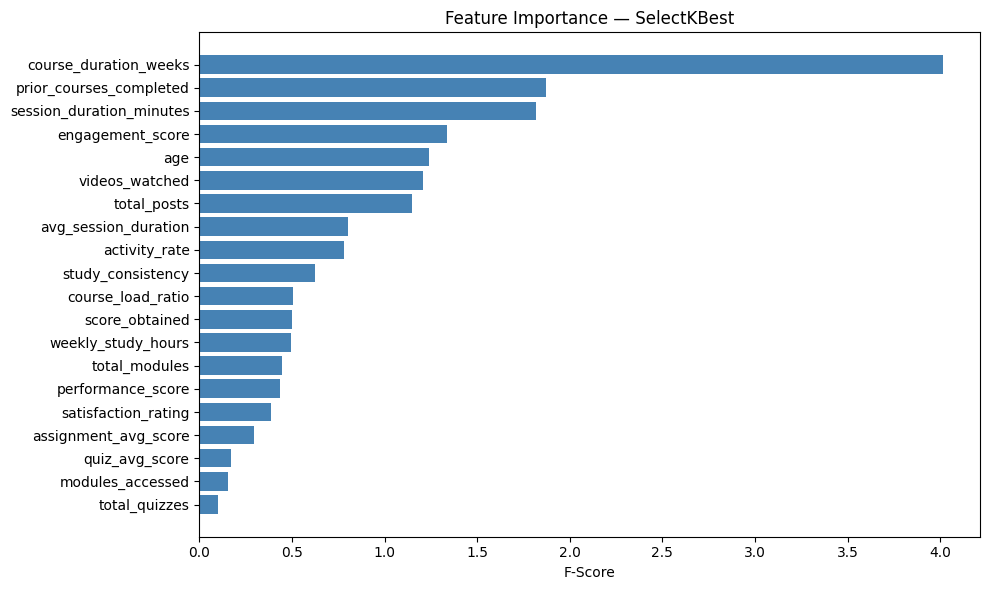

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(scores['Feature'], scores['Score'], color='steelblue')
plt.xlabel('F-Score')
plt.title('Feature Importance — SelectKBest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Discussion Questions:

What does SelectKBest measure and how does it rank features?

Which features scored highest and how does this relate to predicting student completion?

How will the top features identified here guide the classification model in Notebook 3?

**1. What does SelectKBest measure and how does it rank features?**

`SelectKBest` is a feature selection technique from scikit-learn that selects features according to the k highest scores. It measures the relationship between each individual feature and the target variable using a scoring function. In our case, for the 'Online Learning Prediction System' project, we used `f_classif` (ANOVA F-value) as the scoring function.

`f_classif` (ANOVA F-value) measures the difference between the means of the target variable for different groups (in our case, the `completion_status` categories: Complete, Drop, Ongoing) based on the values of a given feature, relative to the variance within those groups. A higher F-value indicates a stronger statistical difference in the feature's values across the target classes, meaning the feature is more discriminative for predicting the `completion_status`.

`SelectKBest` ranks features by these F-scores (or other chosen scoring functions) in descending order, with higher scores indicating greater statistical power for distinguishing between the target classes. It then allows us to select the top 'k' features that are most relevant to our prediction task.

**2. Which features scored highest and how does this relate to predicting student completion?**

Based on the `SelectKBest` results, the features that scored highest are:

1.  `course_duration_weeks`
2.  `prior_courses_completed`
3.  `session_duration_minutes`
4.  `engagement_score`
5.  `age`

These features are highly relevant for predicting `completion_status` in our 'Online Learning Prediction System' project:

*   **`course_duration_weeks`:** This makes intuitive sense. Students might be more likely to complete shorter courses, or perhaps longer courses indicate a higher commitment. A student's ability to commit to longer courses could correlate with their `completion_status`. For instance, students in very long courses might be more prone to dropping due to external factors over time.

*   **`prior_courses_completed`:** This indicates a student's prior experience and success in online learning. Students who have successfully completed more courses in the past are likely more adept at online learning, more motivated, or have developed effective study habits, making them more likely to complete future courses.

*   **`session_duration_minutes`:** This feature directly reflects how much time a student dedicates during a single learning session. Longer or more focused session durations could indicate higher engagement and dedication, which would naturally correlate with a higher likelihood of completing a course.

*   **`engagement_score`:** As its name suggests, this is a composite measure of a student's overall interaction and participation. Higher engagement is a direct indicator of active learning and commitment, strongly linking to success and completion.

*   **`age`:** Age can be a factor in learning behavior and life circumstances. Younger students might have different study patterns or fewer external responsibilities compared to older students, which could influence their `completion_status`.

**3. How will the top features identified here guide the classification model in Notebook 3?**

The top features identified by `SelectKBest` will significantly guide the development of our classification model for predicting `completion_status` in Notebook 3:

*   **Primary Inputs:** These high-scoring features (like `course_duration_weeks`, `prior_courses_completed`, `session_duration_minutes`, `engagement_score`, and `age`) will likely form the core set of input features for our classification model. By prioritizing these features, the model will focus on the most statistically relevant information to make predictions.

*   **Improved Model Performance:** Using only the most informative features can lead to several benefits:
    *   **Reduced Overfitting:** Eliminating irrelevant or weakly predictive features reduces the noise the model has to learn from, making it less likely to overfit the training data and improving its generalization to unseen students.
    *   **Faster Training:** A reduced feature set means lower dimensionality, leading to faster training times for the model.
    *   **Enhanced Interpretability:** A model built on a concise set of strong predictors is easier to understand. We can clearly see which student attributes are driving the `completion_status` predictions, which is valuable for educational interventions or system design.

*   **Strategic Feature Engineering/Re-evaluation:** Features with very low scores might be considered for removal from the dataset entirely, or we might re-evaluate if they can be transformed or combined with other features to create more predictive composite features. This step ensures that our final model is lean, efficient, and highly focused on the strongest signals within the 'Online Learning Prediction System' data.

# **Step 10: Save Processed Dataset**
Task:
Save the processed and feature-selected dataset to Google Drive for use in Notebooks 3 and 4.

In [ ]:
# Keep top 10 features + target
top_features = scores['Feature'].head(10).tolist()
top_features.append('completion_status')

# Add remaining useful categorical columns
cat_cols_to_keep = ['gender', 'region', 'internet_access_type', 'education_level',
                    'employment_status', 'device_type', 'learning_goal',
                    'course_category', 'difficulty_level', 'assessment_type']

final_cols = top_features + [c for c in cat_cols_to_keep if c in df_reduced.columns]
df_processed = df_reduced[final_cols].copy()

# Save
output_path = '/content/drive/MyDrive/Online-Learning-Prediction/Datasets/Processed_OnlineLearning.csv'
df_processed.to_csv(output_path, index=False)

print("Processed dataset saved successfully.")
print(f"Path: {output_path}")
print(f"Final shape: {df_processed.shape}")
print(f"Columns saved: {df_processed.columns.tolist()}")

Processed dataset saved successfully.
Path: /content/drive/MyDrive/Online-Learning-Prediction/Datasets/Processed_OnlineLearning.csv
Final shape: (7000, 21)
Columns saved: ['course_duration_weeks', 'prior_courses_completed', 'session_duration_minutes', 'engagement_score', 'age', 'videos_watched', 'total_posts', 'avg_session_duration', 'activity_rate', 'study_consistency', 'completion_status', 'gender', 'region', 'internet_access_type', 'education_level', 'employment_status', 'device_type', 'learning_goal', 'course_category', 'difficulty_level', 'assessment_type']


# Discussion Questions:

Why is the processed dataset saved separately from the cleaned dataset?

How does the final column selection balance between numerical and categorical features?

What would happen in Notebook 3 if this processed dataset still contained irrelevant or redundant features?

**1. Why is the processed dataset saved separately from the cleaned dataset?**

The processed dataset is saved separately from the initial cleaned dataset for several important reasons, especially in the context of our 'Online Learning Prediction System' project:

*   **Maintain Data Lineage and Reproducibility:** Saving the cleaned dataset as a distinct version (e.g., `Cleaned_OnlineLearning.csv`) allows us to always revert to a baseline where only basic cleaning (handling missing values, basic type conversions) has occurred. The `Processed_OnlineLearning.csv` represents a further stage of data preparation, including feature selection and potential scaling/encoding. This separation makes our workflow reproducible, as we can trace the changes made at each stage.

*   **Clear Separation of Concerns:** The cleaned dataset is suitable for initial exploration, while the processed dataset is specifically optimized for machine learning model training. Separating them ensures that subsequent notebooks (like Notebook 3 for modeling) receive data that has undergone all necessary transformations and feature engineering, without having to re-run all preprocessing steps.

*   **Version Control for Experimentation:** In a data science project, we might experiment with different feature selection methods, normalization techniques, or feature engineering strategies. By saving distinct processed datasets, we can easily switch between different versions of prepared data for model training and comparison, enabling more agile experimentation.

*   **Efficiency for Downstream Tasks:** Notebook 3 and 4 (for modeling and evaluation) can directly load `Processed_OnlineLearning.csv`, saving time and computational resources by not having to re-execute all the data preprocessing steps performed in this notebook. This is particularly valuable for large datasets or complex preprocessing pipelines.

**2. How does the final column selection balance between numerical and categorical features?**

The final column selection in our `df_processed` dataset for the 'Online Learning Prediction System' project achieves a strategic balance between numerical and categorical features:

*   **Prioritization of Predictive Numerical Features:** We specifically included the top 10 numerical features identified by `SelectKBest` (such as `course_duration_weeks`, `prior_courses_completed`, `session_duration_minutes`, `engagement_score`, and `age`). These are the most statistically powerful numerical features for predicting `completion_status`, ensuring that the model leverages their quantitative insights.

*   **Inclusion of Essential Categorical Features:** Alongside the numerical features, we deliberately retained several key categorical features (e.g., `gender`, `region`, `internet_access_type`, `education_level`, `employment_status`, `device_type`, `learning_goal`, `course_category`, `difficulty_level`, `assessment_type`). These categorical features, while not directly ranked by `SelectKBest` in its current numerical application, provide crucial contextual information about students and courses that is vital for understanding and predicting `completion_status`. For instance, `education_level` or `employment_status` could strongly influence a student's ability to complete an online course.

*   **Holistic Representation:** This combined approach ensures that the processed dataset offers a holistic representation of factors influencing student completion: both the quantifiable behaviors/attributes (numerical) and the qualitative contextual information (categorical). The model in Notebook 3 will then be able to utilize both types of data, typically after appropriate encoding for the categorical features, to build a more robust and accurate prediction.

**3. What would happen in Notebook 3 if this processed dataset still contained irrelevant or redundant features?**

If the `Processed_OnlineLearning.csv` dataset, which will be used in Notebook 3 for building our 'Online Learning Prediction System', still contained irrelevant or redundant features, several negative consequences could arise:

*   **Increased Risk of Overfitting:** The model might learn to associate noise or redundant information from these features with the `completion_status`, rather than focusing on the true underlying patterns. This leads to a model that performs well on the training data but poorly on new, unseen student data.

*   **Reduced Model Performance:** Irrelevant features can distract the model from finding the most important relationships, potentially leading to lower accuracy, precision, recall, or F1-score in predicting `completion_status`.

*   **Higher Computational Cost and Longer Training Times:** More features mean a larger input space for the model. This can significantly increase the memory footprint and the time required to train and make predictions, especially for complex models or when performing hyperparameter tuning.

*   **Decreased Model Interpretability:** A model with unnecessary features becomes harder to understand. It's more challenging to pinpoint which factors are genuinely contributing to a student's `completion_status`, making it difficult to extract actionable insights for improving online learning programs.

*   **Curse of Dimensionality:** With too many features relative to the number of samples, the data becomes sparse, and it becomes increasingly difficult for algorithms to find meaningful patterns, leading to poorer generalization. This is why careful feature selection, as performed in this notebook, is critical before moving to the modeling phase.